# Bibliometric Analysis — AI in Offensive and Defensive Cybersecurity

**BUSI 1783 Business Analytics Project**

This notebook reproduces every quantitative figure reported in **Chapter 4, Sections 4.1–4.3**, following the method described in **Methodology Section 3.7**.

### What this notebook does
It counts and plots. Specifically it produces:

| Output | Reported in |
|---|---|
| Publications per year + Poisson growth model | Section 4.1 |
| Conference vs journal split, citation statistics | Section 4.1, Table 4.1 |
| Term prevalence across title/abstract/keywords | Section 4.2, Figure 4.2 |
| Keyword co-occurrence and weighted-degree centrality | Section 4.2 |
| Orientation distribution (189 eligible, 20 selected) | Section 4.3, Table 4.2, Figure 4.3 |
| Figures 4.1, 4.2, 4.3 | Chapter 4 |

### What this notebook does NOT do
It does **not** produce the findings. Every screening decision, orientation code (offensive / defensive / dual-use), quality-based exclusion and thematic interpretation was a **human judgement**, recorded in the screening spreadsheet. This notebook only tabulates and visualises the results of those judgements.

The thematic synthesis in **Sections 4.4–4.6 was carried out by hand**, without coding software, as stated in Methodology Section 3.8. There is deliberately no code for it here.

### Inputs
- `Scopus_209_Title_Abstract_Screening.xlsx` — the 209 screened records with manual screening decisions
- `scopus_export.ris` — the raw 12,500-record Scopus export (used only for citation counts)

## 0. Setup

In [1]:
import re
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ---- File paths: edit these to match your folder layout -----------------
DATA = Path("data")
SCREENING_XLSX = DATA / "Scopus_209_Title_Abstract_Screening.xlsx"
RIS_FILE       = DATA / "scopus_export.ris"
FIGDIR = Path("outputs"); FIGDIR.mkdir(exist_ok=True)

# ---- Plot styling ------------------------------------------------------
NAVY, RED, GOLD = "#1F4E78", "#B22222", "#B8860B"
plt.rcParams.update({
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#666666",
    "figure.dpi": 120,
})

print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.8


## 1. Load the screened corpus

The spreadsheet holds one row per screened record. The columns produced by **manual screening** are `Decision`, `Primary_Side`, `Evidence_Type` and `Confidence` — the notebook reads these, it does not generate them.

In [2]:
df = pd.read_excel(SCREENING_XLSX, sheet_name="Screening_209")
print(f"Records loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
df[["Paper_ID", "Year", "Title", "Publication_Type", "Decision", "Primary_Side"]].head()

Records loaded: 209
Columns: ['Paper_ID', 'Year', 'Title', 'Authors', 'Publication_Type', 'Source_Title', 'DOI', 'Scopus_URL', 'Abstract', 'Keywords', 'Decision', 'Screening_Reason', 'Confidence', 'Primary_Side', 'AI_Technique', 'Cybersecurity_Area', 'Application_Context', 'Evidence_Type', 'Full_Text_Next_Step']


,Paper_ID,Year,Title,Publication_Type,Decision,Primary_Side
0,1,2023,Hybrid AI-Based iBeacon Indoor Positioning Cyb...,Conference paper,Include,Both / dual-use
1,2,2023,AI and IoT based Intrusion Detection System fo...,Conference paper,Include,Defensive
2,3,2024,A Proposed MalwareNexus Framework for Cybersec...,Conference paper,Maybe,Defensive
3,4,2017,Network intrusion detection for cyber security...,Conference paper,Include,Defensive
4,5,2024,ML-SPAs: Fortifying Healthcare Cybersecurity L...,Article,Include,Defensive


In [3]:
# Sanity checks — these must hold before any analysis is trusted
assert len(df) == 209, "Expected 209 screened records"
assert df["Paper_ID"].is_unique, "Paper_ID must be unique"

print("Missing abstracts:", df["Abstract"].isna().sum())
print("Missing keywords :", df["Keywords"].isna().sum())
print("Duplicate titles :", df["Title"].str.strip().str.lower().duplicated().sum())
print("Duplicate DOIs   :", df["DOI"].dropna().str.strip().str.lower().duplicated().sum())
print("\nScreening decisions:")
print(df["Decision"].value_counts())

Missing abstracts: 0
Missing keywords : 0
Duplicate titles : 0
Duplicate DOIs   : 0

Screening decisions:
Decision
Include    194
Maybe       13
Exclude      2
Name: count, dtype: int64


## 2. Section 4.1 — Corpus profile

### 2.1 Publications per year

In [4]:
year_counts = df["Year"].astype(int).value_counts().sort_index()
print(year_counts.to_string())
print(f"\nTotal: {year_counts.sum()}")

Year
2017      1
2018      3
2019      4
2020     14
2021      9
2022     22
2023     51
2024    105

Total: 209


### 2.2 Poisson growth model

Publication counts are **count data** (non-negative integers), so a Poisson generalised linear model is the appropriate choice rather than ordinary linear regression.

The model is `log(count) = b0 + b1 x (year - 2017)`. Exponentiating the slope gives the **incidence-rate ratio (IRR)** — the multiplicative change in expected publications per additional year. An IRR of 1.90 means the expected count is ~1.9x higher each year.

In [5]:
years  = year_counts.index.values.astype(float)
counts = year_counts.values.astype(float)

X = sm.add_constant(years - years.min())          # centre on the first year (2017)
model = sm.GLM(counts, X, family=sm.families.Poisson()).fit()

slope, se = model.params[1], model.bse[1]
irr    = np.exp(slope)
ci_low, ci_high = np.exp(slope - 1.96 * se), np.exp(slope + 1.96 * se)
pval   = model.pvalues[1]

print(f"IRR              : {irr:.3f}")
print(f"95% CI           : {ci_low:.3f} to {ci_high:.3f}")
print(f"p-value          : {pval:.3e}")
print(f"Annual growth    : {(irr - 1) * 100:.1f}%")
print("\nReported in Section 4.1 as: IRR 1.90 per year (p < 0.001)")

IRR              : 1.897
95% CI           : 1.722 to 2.089
p-value          : 1.285e-38
Annual growth    : 89.7%

Reported in Section 4.1 as: IRR 1.90 per year (p < 0.001)


> **Interpretation caveat (stated in Section 4.1):** this measures growth in the *literature captured by this search query*. It does **not** measure growth in cyber attacks themselves.

### 2.3 Document type and citation statistics

In [6]:
doc_counts = df["Publication_Type"].value_counts()
for k, v in doc_counts.items():
    print(f"{k:20s} {v:4d}  ({v/len(df)*100:.1f}%)")

Conference paper      138  (66.0%)
Article                71  (34.0%)


In [7]:
# Citation counts are not in the screening sheet, so they are recovered from the
# raw RIS export by matching on DOI.
def parse_ris_citations(path):
    """Return {doi: cited_by} from a Scopus RIS export."""
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    out = {}
    for record in text.split("\nER  -"):
        doi = re.search(r"DO\s*-\s*(.+)", record)
        cit = re.search(r"Cited By:\s*(\d+)", record)
        if doi:
            out[doi.group(1).strip().lower()] = int(cit.group(1)) if cit else 0
    return out

if RIS_FILE.exists():
    ris_citations = parse_ris_citations(RIS_FILE)
    print(f"DOIs found in RIS export: {len(ris_citations)}")

    dois = df["DOI"].dropna().str.strip().str.lower()
    matched = [ris_citations[d] for d in dois if d in ris_citations]

    print(f"Screened records with a DOI     : {len(dois)}")
    print(f"Matched to a citation count     : {len(matched)}")
    print(f"\nMedian citations: {int(np.median(matched))}")
    print(f"Mean citations  : {np.mean(matched):.1f}")
    print(f"Max citations   : {max(matched)}")
    print("\nNote: the mean is ~4x the median, so a few highly cited surveys")
    print("dominate the average. Citations were NOT used as an inclusion threshold.")
else:
    print("RIS file not found - skipping citation statistics.")

DOIs found in RIS export: 12070
Screened records with a DOI     : 200
Matched to a citation count     : 167

Median citations: 7
Mean citations  : 29.6
Max citations   : 415

Note: the mean is ~4x the median, so a few highly cited surveys
dominate the average. Citations were NOT used as an inclusion threshold.


## 3. Section 4.2 — Term prevalence and keyword network

### 3.1 Term prevalence

Counts are **non-exclusive**: one record can contain several terms, so the counts do not sum to 209. A record counts once per term regardless of how many times the term appears.

In [8]:
SEARCH_FIELDS = ["Title", "Abstract", "Keywords"]

TERMS = {
    "Machine learning":       ["machine learning"],
    "Deep learning":          ["deep learning"],
    "Intrusion detection":    ["intrusion detection"],
    "Adversarial":            ["adversarial"],
    "Threat detection":       ["threat detection"],
    "Malware":                ["malware"],
    "Internet of Things":     ["internet of things", "iot"],
    "Phishing":               ["phishing"],
    "Reinforcement learning": ["reinforcement learning"],
    "Penetration testing":    ["penetration testing", "pentest"],
    "Generative AI / LLM":    ["generative ai", "large language model", "llm", "chatgpt", "gpt-"],
}

def record_text(row):
    """Concatenate the searchable fields of one record into lowercase text."""
    return " ".join(str(row[f] or "") for f in SEARCH_FIELDS).lower()

corpus = df.apply(record_text, axis=1)

term_counts = {
    label: int(corpus.apply(lambda t: any(p in t for p in patterns)).sum())
    for label, patterns in TERMS.items()
}

term_series = pd.Series(term_counts).sort_values(ascending=False)
print(term_series.to_string())

Machine learning          145
Deep learning              90
Intrusion detection        71
Adversarial                61
Threat detection           44
Malware                    44
Internet of Things         42
Phishing                   36
Reinforcement learning      5
Penetration testing         3
Generative AI / LLM         1


> Term frequency reflects **how authors label their work**, not what the paper actually does. An adversarial-ML paper may be dense with intrusion-detection language while its contribution is an attack. This is why Section 4.3 uses the manual orientation coding instead.

### 3.2 Keyword co-occurrence network

Two keywords **co-occur** when they appear on the same record. **Weighted degree** is the sum of a keyword's co-occurrence counts — how strongly it connects to everything else in the network.

In [9]:
# Common spelling variants are normalised so they are not counted as separate nodes
NORMALISE = {
    "cyber security": "cybersecurity", "cyber-security": "cybersecurity",
    "machine-learning": "machine learning", "ml": "machine learning",
    "deep-learning": "deep learning", "dl": "deep learning",
    "ai": "artificial intelligence",
    "intrusion detection systems": "intrusion detection system",
    "intrusion detection": "intrusion detection system",
    "ids": "intrusion detection system",
}

def split_keywords(cell):
    """Split a Scopus keyword cell into a normalised set of keywords."""
    if pd.isna(cell) or not str(cell).strip():
        return set()
    parts = [k.strip().lower() for k in re.split(r"[;|]", str(cell)) if k.strip()]
    return {NORMALISE.get(p, p) for p in parts}

keyword_sets = df["Keywords"].apply(split_keywords)

freq = collections.Counter()
for s in keyword_sets:
    freq.update(s)

print("TOP KEYWORDS BY FREQUENCY")
for k, n in freq.most_common(10):
    print(f"  {k:32s} {n:4d}")

TOP KEYWORDS BY FREQUENCY
  cybersecurity                     184
  machine learning                  106
  network security                   73
  deep learning                      70
  intrusion detection system         63
  learning systems                   49
  cyber attacks                      45
  computer crime                     44
  adversarial machine learning       41
  artificial intelligence            40


In [10]:
# Co-occurrence: count each unordered pair once per record
import itertools

pairs = collections.Counter()
for s in keyword_sets:
    for a, b in itertools.combinations(sorted(s), 2):
        pairs[(a, b)] += 1

print("STRONGEST KEYWORD PAIRS")
for (a, b), n in pairs.most_common(8):
    print(f"  {a} -- {b}: {n}")

# Weighted degree = total co-occurrence weight attached to each keyword
weighted_degree = collections.Counter()
for (a, b), n in pairs.items():
    weighted_degree[a] += n
    weighted_degree[b] += n

print("\nWEIGHTED-DEGREE CENTRALITY (top 8)")
for k, n in weighted_degree.most_common(8):
    print(f"  {k:32s} {n:5d}")

STRONGEST KEYWORD PAIRS
  cybersecurity -- machine learning: 95
  cybersecurity -- deep learning: 67
  cybersecurity -- network security: 65
  cybersecurity -- intrusion detection system: 54
  cybersecurity -- learning systems: 48
  cyber attacks -- cybersecurity: 42
  computer crime -- cybersecurity: 40
  adversarial machine learning -- cybersecurity: 39

WEIGHTED-DEGREE CENTRALITY (top 8)
  cybersecurity                     2773
  machine learning                  1543
  network security                  1256
  deep learning                     1098
  intrusion detection system         979
  learning systems                   885
  computer crime                     789
  cyber attacks                      689


## 4. Section 4.3 — Orientation distribution

`Primary_Side` is a **manual code** assigned during screening. The lists below record the outcome of the full-text eligibility stage and the stratified sampling decision — both human judgements, documented in the eligibility tracker.

In [11]:
# 18 records excluded at full-text eligibility, grouped by reason (Section 3.4)
EXCLUDED = {
    "duplicate":        [1],
    "framework_only":   [3, 63, 92, 160, 200, 205],
    "opinion_piece":    [23],
    "venue_quality":    [5, 10, 13, 29, 75, 121, 132, 144, 169, 204],
}
excluded_ids = [pid for group in EXCLUDED.values() for pid in group]

# The 20 studies chosen for thematic synthesis (Section 3.6)
SELECTED = [71, 78, 82, 86,                                    # offensive
            20, 41, 50, 123, 130, 139, 165, 182, 188, 207, 208, # dual-use
            83, 110, 184, 195, 199]                             # defensive

for reason, ids in EXCLUDED.items():
    print(f"{reason:16s} {len(ids):3d}")
print(f"{'TOTAL EXCLUDED':16s} {len(excluded_ids):3d}")
print(f"\nSelected for synthesis: {len(SELECTED)}")

assert len(excluded_ids) == 18
assert len(SELECTED) == 20

duplicate          1
framework_only     6
opinion_piece      1
venue_quality     10
TOTAL EXCLUDED    18

Selected for synthesis: 20


In [12]:
# Eligible pool = records that reached full text (207) minus the 18 excluded
reached_full_text = df[df["Decision"].isin(["Include", "Maybe"])]
eligible = reached_full_text[~reached_full_text["Paper_ID"].isin(excluded_ids)]
selected = df[df["Paper_ID"].isin(SELECTED)]

print(f"Screened            : {len(df)}")
print(f"Reached full text   : {len(reached_full_text)}")
print(f"Eligible            : {len(eligible)}")
print(f"Selected            : {len(selected)}")

LABEL = {"Defensive": "Defensive", "Both / dual-use": "Dual-use", "Offensive": "Offensive"}
ORDER = ["Defensive", "Dual-use", "Offensive"]

elig_counts = eligible["Primary_Side"].map(LABEL).value_counts().reindex(ORDER).fillna(0).astype(int)
sel_counts  = selected["Primary_Side"].map(LABEL).value_counts().reindex(ORDER).fillna(0).astype(int)

table_43 = pd.DataFrame({
    "Eligible (n=189)":  elig_counts,
    "Eligible %":        (elig_counts / elig_counts.sum() * 100).round(1),
    "Synthesis (n=20)":  sel_counts,
    "Synthesis %":       (sel_counts / sel_counts.sum() * 100).round(0),
})
print()
print(table_43.to_string())

ratio = (elig_counts["Defensive"] + elig_counts["Dual-use"]) / elig_counts["Offensive"]
print(f"\nDefensive + dual-use : offensive = {ratio:.0f} to 1")

Screened            : 209
Reached full text   : 207
Eligible            : 189
Selected            : 20

              Eligible (n=189)  Eligible %  Synthesis (n=20)  Synthesis %
Primary_Side                                                             
Defensive                  166        87.8                 5         25.0
Dual-use                    19        10.1                11         55.0
Offensive                    4         2.1                 4         20.0

Defensive + dual-use : offensive = 46 to 1


> The left column **measures the field**. The right column is a **design decision** — the synthesis set was deliberately stratified to over-represent offensive and dual-use work, so its proportions must not be read as a property of the literature.

## 5. Figures

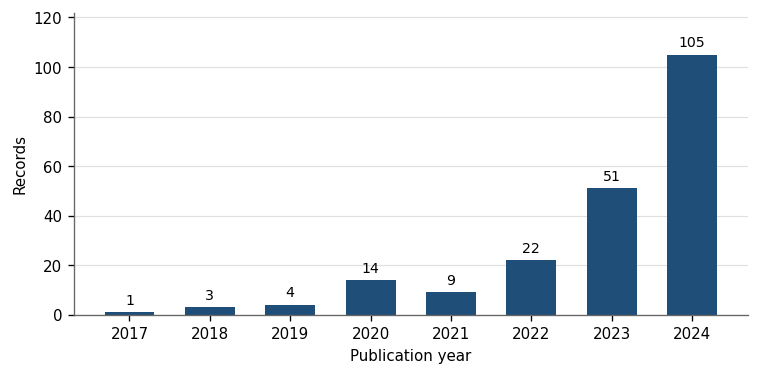

In [13]:
# ---- Figure 4.1: publications per year ----------------------------------
fig, ax = plt.subplots(figsize=(6.4, 3.2))
bars = ax.bar(year_counts.index.astype(str), year_counts.values, color=NAVY, width=0.62)
for b, v in zip(bars, year_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 2, str(v), ha="center", va="bottom", fontsize=8.5)
ax.set_xlabel("Publication year"); ax.set_ylabel("Records")
ax.set_ylim(0, year_counts.max() * 1.16)
ax.grid(axis="y", color="#E0E0E0", linewidth=0.7); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGDIR / "figure_4_1.png", bbox_inches="tight", dpi=200)
plt.show()

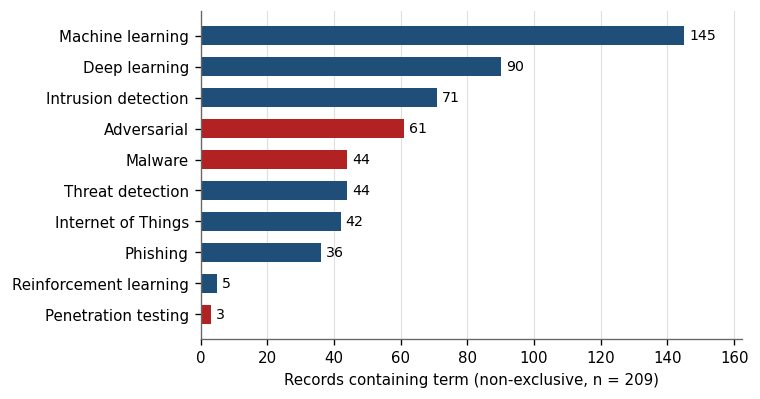

In [14]:
# ---- Figure 4.2: term prevalence ---------------------------------------
plot_terms = term_series.drop("Generative AI / LLM").sort_values()
OFFENSIVE_TERMS = {"Adversarial", "Malware", "Penetration testing"}
colors = [RED if t in OFFENSIVE_TERMS else NAVY for t in plot_terms.index]

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.barh(plot_terms.index, plot_terms.values, color=colors, height=0.62)
for b, v in zip(bars, plot_terms.values):
    ax.text(v + 1.5, b.get_y() + b.get_height()/2, str(v), va="center", fontsize=8.5)
ax.set_xlabel(f"Records containing term (non-exclusive, n = {len(df)})")
ax.set_xlim(0, plot_terms.max() * 1.12)
ax.grid(axis="x", color="#E0E0E0", linewidth=0.7); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGDIR / "figure_4_2.png", bbox_inches="tight", dpi=200)
plt.show()

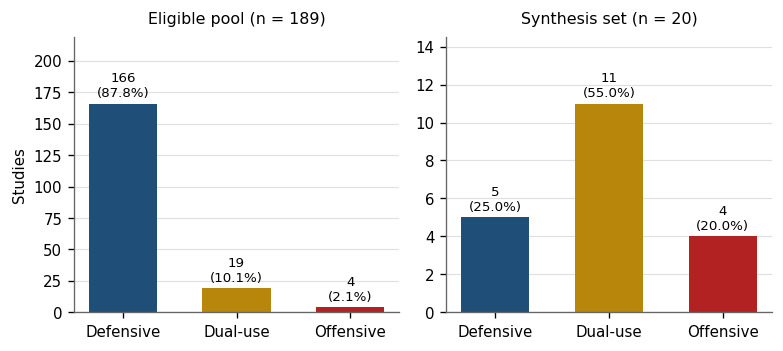

In [15]:
# ---- Figure 4.3: orientation, eligible pool vs synthesis set ------------
fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.0))
cols = [NAVY, GOLD, RED]

for ax, data, title in zip(axes, [elig_counts, sel_counts],
                           [f"Eligible pool (n = {elig_counts.sum()})",
                            f"Synthesis set (n = {sel_counts.sum()})"]):
    bars = ax.bar(data.index, data.values, color=cols, width=0.6)
    for b, v in zip(bars, data.values):
        ax.text(b.get_x() + b.get_width()/2, v + data.max()*0.02,
                f"{v}\n({v/data.sum()*100:.1f}%)", ha="center", va="bottom", fontsize=8)
    ax.set_title(title, fontsize=9.5, pad=8)
    ax.set_ylim(0, data.max() * 1.32)
    ax.grid(axis="y", color="#E0E0E0", linewidth=0.7); ax.set_axisbelow(True)

axes[0].set_ylabel("Studies")
fig.tight_layout(); fig.savefig(FIGDIR / "figure_4_3.png", bbox_inches="tight", dpi=200)
plt.show()

## 6. Summary of reported values

Every number below appears in Chapter 4. Run this cell to confirm the chapter and the code agree.

In [16]:
summary = pd.DataFrame([
    ("Records screened",              len(df)),
    ("Reached full-text assessment",  len(reached_full_text)),
    ("Met eligibility criteria",      len(eligible)),
    ("Selected for synthesis",        len(selected)),
    ("Conference papers",             int(doc_counts.get("Conference paper", 0))),
    ("Journal articles",              int(doc_counts.get("Article", 0))),
    ("Poisson IRR (per year)",        round(irr, 3)),
    ("Poisson p-value",               f"{pval:.2e}"),
    ("Defensive (eligible)",          int(elig_counts["Defensive"])),
    ("Dual-use (eligible)",           int(elig_counts["Dual-use"])),
    ("Offensive (eligible)",          int(elig_counts["Offensive"])),
    ("Defensive+dual : offensive",    f"{ratio:.0f} to 1"),
], columns=["Measure", "Value"])

print(summary.to_string(index=False))
print(f"\nFigures written to: {FIGDIR.resolve()}")

                     Measure    Value
            Records screened      209
Reached full-text assessment      207
    Met eligibility criteria      189
      Selected for synthesis       20
           Conference papers      138
            Journal articles       71
      Poisson IRR (per year)    1.897
             Poisson p-value 1.29e-38
        Defensive (eligible)      166
         Dual-use (eligible)       19
        Offensive (eligible)        4
  Defensive+dual : offensive  46 to 1

Figures written to: /home/claude/nb/outputs
